# Truncated-SVD regularization of wavefront reconstruction

**Scientific question.** A Shack–Hartmann interaction matrix has a spread of
singular values; the smallest ones correspond to poorly sensed actuator
combinations. How does the truncation threshold `rcond` trade recovered signal
against amplified measurement noise when reconstructing a known deformable-
mirror command from noisy slopes?

Calibration, the SVD, and the truncated-SVD reconstructor are all installed
`shwfs_ao` APIs.

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from shwfs_ao.calibration import (
    DmActuatorProbeBasis,
    TsvdReconstructor,
    calibrate_interaction_matrix,
    interaction_diagnostics,
)
from shwfs_ao.backends.native.shwfs import NativeShackHartmannOptics
from shwfs_ao.core.random import NamedRandomStreams
from shwfs_ao.core.types import DmCommandVector
from shwfs_ao.detector.config import DetectorConfig
from shwfs_ao.dm import DMConfig, build_native_deformable_mirror
from shwfs_ao.wfs.shack_hartmann.geometry import build_shack_hartmann_geometry
from shwfs_ao.wfs.shack_hartmann.measurement import (
    build_detector_shack_hartmann_sensor,
)

SEED = 20240517
TELESCOPE_DIAMETER_M = 1.0
WFS_WAVELENGTH_M = 700e-9
RCOND_VALUES = (0.8, 0.5, 0.35, 0.3, 0.1, 0.03, 0.01, 0.003, 0.001)

## Configuration

The Gaussian DM keeps the declared synthetic width/pitch of 0.35. This is a
controlled reconstruction example, not a model of a particular measured mirror.
The cutoff scan deliberately spans the measured normalized singular spectrum
so that several different numbers of modes are retained.

In [3]:
geometry = build_shack_hartmann_geometry(
    telescope_diameter_m=TELESCOPE_DIAMETER_M,
    pupil_shape=(60, 60),
    n_lenslets_across=6,
    min_fill_fraction=0.4,
)
optics = NativeShackHartmannOptics(geometry, WFS_WAVELENGTH_M, pad_factor=8)
sensor = build_detector_shack_hartmann_sensor(
    geometry,
    optics,
    DetectorConfig(photons_per_subap_frame=4e3),
    wfs_wavelength_m=WFS_WAVELENGTH_M,
    random_streams=NamedRandomStreams(SEED),
)
mirror = build_native_deformable_mirror(
    geometry.x_m,
    geometry.y_m,
    geometry.pupil_mask,
    DMConfig(
        telescope_diameter_m=TELESCOPE_DIAMETER_M,
        n_actuators_across=7,
        coupling_width_pitch=0.35,
        stroke_limit_nm=20000.0,
    ),
)
interaction = calibrate_interaction_matrix(
    DmActuatorProbeBasis(mirror),
    sensor,
    amplitude_m=25e-9,
    random_streams=NamedRandomStreams(SEED).scoped("calibration-probe"),
    include_noise=False,
)
diagnostics = interaction_diagnostics(
    np.asarray(interaction.matrix), np.asarray(interaction.row_valid)
)

## Simulation call

In [4]:
rng = np.random.default_rng(SEED)
true_command = 80e-9 * rng.standard_normal(mirror.n_actuators)
target_opd_m = mirror.opd_from_commands(
    DmCommandVector(
        values_opd_m=true_command,
        actuator_ids=mirror.actuator_ids,
        command_unit="m_opd_equivalent",
    )
).correction_opd_m
noisy = sensor.measure(
    target_opd_m, random_streams=NamedRandomStreams(SEED), include_noise=True
)

def recover(rcond):
    reconstructor = TsvdReconstructor(
        interaction, rcond=rcond, min_valid_fraction=0.5, min_rank=1
    )
    estimate = reconstructor.reconstruct(noisy.vector)
    recovered = np.asarray(estimate.delta_coordinates_opd_m, dtype=float)
    command_error = np.sqrt(np.mean((recovered - true_command) ** 2))
    return int(estimate.kept_modes), float(command_error)

results = {rcond: recover(rcond) for rcond in RCOND_VALUES}

## Diagnostic table

In [5]:
singular = np.asarray(diagnostics.singular_values, dtype=float)
normalized = singular / singular[0]
kept = np.array([results[r][0] for r in RCOND_VALUES])
errors_nm = np.array([results[r][1] * 1e9 for r in RCOND_VALUES])
assert np.unique(kept).size >= 3, "Cutoffs must exercise different retained ranks."
assert np.all(np.diff(kept) >= 0), "Lower cutoffs must not discard more modes."
assert np.all(np.isfinite(errors_nm))
if np.all(noisy.vector.valid_rows):
    assert np.array_equal(kept, [np.count_nonzero(normalized > r) for r in RCOND_VALUES])
for rank in np.unique(kept):
    assert np.allclose(errors_nm[kept == rank], errors_nm[kept == rank][0],
                       rtol=1e-10, atol=1e-10)
best_error_nm = float(np.min(errors_nm))
best_cutoffs = [r for r, error in zip(RCOND_VALUES, errors_nm)
                if np.isclose(error, best_error_nm, rtol=1e-10, atol=1e-10)]
print(f"Normalized singular values span {normalized[-1]:.4f} to {normalized[0]:.1f}.")
print(f"Minimum error in this realization: {best_error_nm:.3f} nm; "
      f"tied rcond values: {best_cutoffs}")
table = pd.DataFrame(
    {"rcond": RCOND_VALUES, "kept modes": kept, "command RMS error (nm)": errors_nm}
)
table

Normalized singular values span 0.3122 to 1.0.
Minimum error in this realization: 8.578 nm; tied rcond values: [0.3, 0.1, 0.03, 0.01, 0.003, 0.001]


,rcond,kept modes,command RMS error (nm)
0,0.800,12,62.941932
1,0.500,24,43.222211
2,0.350,27,17.661750
3,0.300,29,8.578094
4,0.100,29,8.578094
5,0.030,29,8.578094
6,0.010,29,8.578094
7,0.003,29,8.578094
8,0.001,29,8.578094


## Plot

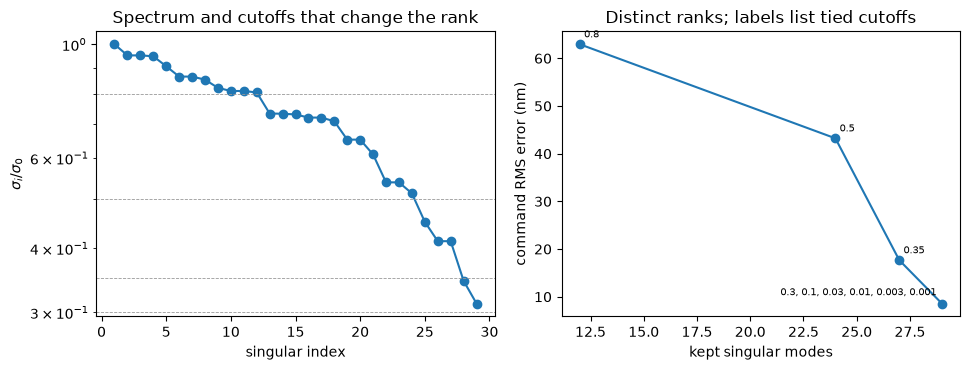

In [6]:
figure, (left, right) = plt.subplots(1, 2, figsize=(9.8, 3.8))
left.semilogy(np.arange(1, normalized.size + 1), normalized, "o-")
for cutoff in RCOND_VALUES[:4]:
    left.axhline(cutoff, color="0.6", linewidth=0.6, linestyle="--")
left.set_xlabel("singular index")
left.set_ylabel(r"$\sigma_i / \sigma_0$")
left.set_title("Spectrum and cutoffs that change the rank")
rank_rows = table.groupby("kept modes", sort=True)
unique_ranks = []
unique_errors_nm = []
for rank, rows in rank_rows:
    error_nm = float(rows["command RMS error (nm)"].iloc[0])
    unique_ranks.append(rank)
    unique_errors_nm.append(error_nm)
    cutoffs = ", ".join(f"{r:g}" for r in rows["rcond"])
    right.annotate(cutoffs, (rank, error_nm), textcoords="offset points",
                   xytext=(-4, 6) if rank == int(np.max(kept)) else (3, 5),
                   ha="right" if rank == int(np.max(kept)) else "left", fontsize=7)
right.plot(unique_ranks, unique_errors_nm, "o-")
right.set_xlabel("kept singular modes")
right.set_ylabel("command RMS error (nm)")
right.set_title("Distinct ranks; labels list tied cutoffs")
figure.tight_layout()
plt.show()

## Interpretation

The chosen cutoffs now cross the singular spectrum and genuinely discard
modes. Cutoffs below the smallest normalized singular value retain the full
calibrated rank and give the same reconstruction: they are tied settings,
not evidence for a uniquely optimal threshold. The printed minimum lists
all tied cutoffs for this one command and noise realization.

An error-versus-retained-rank plot is not an L-curve (which compares residual
norm with solution norm). This example measures what this data set supports;
it does not assume that a noise-suppression optimum or an elbow must appear.
Discarding sensed modes can simply increase the command error in this case.

## Limitations

- One noisy measurement and one random command are used. A defensible tuning
  study would average multiple commands and noise realizations at each flux.
- The retained synthetic influence width affects the singular spectrum.
- The target's detector measurement can include optical nonlinearity as well
  as noise; the interaction matrix is a finite-amplitude calibration.
- `min_rank` and `min_valid_fraction` remain fixed safeguards.